In [1]:
from pathlib import Path
import warnings
import math

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from results.repetition import RepetitionResults
from results.results import Results
from results.topology_results import TopologyResults

## Configuration


### Path Configuration


In [2]:
RES_PARENT_FOLDER = Path("../../results").resolve()
RES_PARENT_FOLDER.mkdir(exist_ok=True)
# BATCH_RES = RES_PARENT_FOLDER / "batch_20260204_17-30-33"
BATCH_RES = RES_PARENT_FOLDER / "batch_20260206_21-45-57"

TOPOLOGY_TO_ANALYSE = "random_20N"
TOPO_RES = BATCH_RES / TOPOLOGY_TO_ANALYSE


if not TOPO_RES.exists():
    raise FileNotFoundError(f"Results folder not found: {TOPO_RES}")

### Plot Style


In [3]:
# Time window size (in seconds) to aggregate parent changes
TIME_BIN_SIZE_S = 5.0

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

## Main Analysis


In [4]:
print(f"Analyizing Topology: {TOPOLOGY_TO_ANALYSE}")

res = Results.from_folder(BATCH_RES)
# topo_res = TopologyResults.from_folder(TOPO_RES)
# topo_res = 11

Analyizing Topology: random_20N
Reading topology results from folder: linear_20N
Reading topology results from folder: ring_20N
Reading topology results from folder: random_20N
Reading topology results from folder: star_20N
Reading topology results from folder: grid_20N


In [5]:
results = pd.DataFrame(
    columns=[
        "topology",
        "configuration",
        "seed",
        "pdr",
        "latency",
        "par_changes",
        "mean_interarrival",
        "true_mean_interarrival",
    ]
)

rows = []

# --- DATA COLLECTION PHASE ---
print("Collecting data from files...")
for topo_res in res.topologies:
    for channel_res in topo_res.channels:
        print(f"  > Processing config: {channel_res.channel_type}")

        for rep in channel_res.repetitions:
            repetition_data = {
                "channel": channel_res.channel_type,
                "topology": topo_res.topology_type,
                "seed": rep.id,
                "mean_interarrival": rep.compute_interarrivals()["inter_arrival"].mean(),
                "true_mean_interarrival": rep.mean_inter_arrival_time,
            }

            # PDR
            p = rep.pdr_df["delivered"].mean() if rep.pdr_df is not None else 0
            repetition_data["pdr"] = p

            # Latency
            l = rep.latency_df["latency"] if rep.latency_df is not None else None
            repetition_data["latency"] = np.mean(l) if l is not None else None

            rows.append(repetition_data)

results = pd.DataFrame(rows)

  > Processing config: ideal
  > Processing config: stable
  > Processing config: stable_mid_pl
  > Processing config: stable_high_pl
  > Processing config: lossy
  > Processing config: unstable
  > Processing config: ideal
  > Processing config: stable
  > Processing config: stable_mid_pl
  > Processing config: stable_high_pl
  > Processing config: lossy
  > Processing config: unstable
  > Processing config: ideal
  > Processing config: stable
  > Processing config: stable_mid_pl
  > Processing config: stable_high_pl
  > Processing config: lossy
  > Processing config: unstable
  > Processing config: ideal
  > Processing config: stable
  > Processing config: stable_mid_pl
  > Processing config: stable_high_pl
  > Processing config: lossy
  > Processing config: unstable
  > Processing config: ideal
  > Processing config: stable
  > Processing config: stable_mid_pl
  > Processing config: stable_high_pl
  > Processing config: lossy
  > Processing config: unstable


### Adjust NaN values in results DataFrame

In [6]:
results["pdr"] = results["pdr"].fillna(0)

Are there any NaN values in any column of the results DataFrame?

In [7]:
print(results.isna().sum())

channel                     0
topology                    0
seed                        0
mean_interarrival           0
true_mean_interarrival      0
pdr                         0
latency                   259
dtype: int64


In [8]:
results

,channel,topology,seed,mean_interarrival,true_mean_interarrival,pdr,latency
0,ideal,linear_20N,12350,53.601600,60.0,0.996633,0.006434
1,ideal,linear_20N,12346_antithetic,62.459145,60.0,0.992095,0.006487
2,ideal,linear_20N,12347_antithetic,53.977750,60.0,0.994932,0.006523
3,ideal,linear_20N,12348_antithetic,58.058864,60.0,0.992714,0.006452
4,ideal,linear_20N,12345_antithetic,54.289619,60.0,0.993197,0.006336
...,...,...,...,...,...,...,...
2995,unstable,grid_20N,12392_antithetic,55.531176,60.0,0.622018,0.021607
2996,unstable,grid_20N,12393,54.136835,60.0,0.729776,0.020542
2997,unstable,grid_20N,12393_antithetic,56.006149,60.0,0.696133,0.020632
2998,unstable,grid_20N,12394,54.848554,60.0,0.713274,0.021628


## Evaluation of Correlation between IT and PDR inside a Single Run

In order to understand if it is better to use the singe values of the simulation (instead of a single metric per run) for the control variate technique, we need to evaluate if there is a correlation between the inter-arrival times and the packet delivery results.

In [9]:
rep = RepetitionResults.from_folder(TOPO_RES / "lossy" / "12385_antithetic")

interarrivals_df = rep.compute_interarrivals()


interarrivals_df["source"] = (
    interarrivals_df["node_id"]
    .dropna()
    .str.replace("Node-", "", regex=False)
    .map(lambda x: f"{int(x):04x}")
)

print(rep.pdr_df)
interarrivals_df

    source_addr  seq_num dest_addr  delivered
0          0011        1      0003          0
1          0003        1      0006          1
2          0003        2      0012          0
3          000d        1      0002          0
4          000b        1      0004          1
..          ...      ...       ...        ...
501        000b       28      000c          0
502        0007       22      000d          0
503        0009       33      000f          1
504        000b       29      0014          1
505        0014       25      0008          0

[506 rows x 4 columns]


,time,event,node_id,type,seq_num,dest,source,hops,reason,inter_arrival
21,130.233432,SEND,Node-17,DATA,1.0,0003,0011,NaN,NaN,0.000000
23,130.372490,SEND,Node-3,DATA,1.0,0006,0003,NaN,NaN,0.000000
25,131.869299,SEND,Node-3,DATA,2.0,0012,0003,NaN,NaN,1.496809
27,133.974070,SEND,Node-13,DATA,1.0,0002,000d,NaN,NaN,0.000000
29,134.517632,SEND,Node-11,DATA,1.0,0004,000b,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...
901,1797.064951,SEND,Node-11,DATA,28.0,000c,000b,NaN,NaN,5.255804
902,1798.268788,SEND,Node-7,DATA,22.0,000d,0007,NaN,NaN,75.038073
903,1799.365659,SEND,Node-9,DATA,33.0,000f,0009,NaN,NaN,128.318458
905,1799.432215,SEND,Node-11,DATA,29.0,0014,000b,NaN,NaN,2.367264


In [10]:
inter_df = interarrivals_df.rename(
    columns={
        "source": "source_addr",
        "dest": "dest_addr",
        "seq_num": "seq_num",
    }
)

pdrs_df = rep.pdr_df.rename(
    columns={
        "source_addr": "source_addr",
        "dest_addr": "dest_addr",
        "seq_num": "seq_num",
    }
)

In [11]:
inter_df["source_addr"] = inter_df["source_addr"].astype(str)
inter_df["dest_addr"] = inter_df["dest_addr"].astype(str)
inter_df["seq_num"] = inter_df["seq_num"].astype(int)

pdrs_df["source_addr"] = pdrs_df["source_addr"].astype(str)
pdrs_df["dest_addr"] = pdrs_df["dest_addr"].astype(str)
pdrs_df["seq_num"] = pdrs_df["seq_num"].astype(int)

In [12]:
joined = inter_df.merge(
    pdrs_df,
    on=["source_addr", "dest_addr", "seq_num"],
    how="outer",
    indicator=True,
    suffixes=("_send", "_pdr"),
)

In [13]:
unmatched = joined[joined["_merge"] != "both"]
print(unmatched["_merge"].value_counts())

_merge
left_only     74
right_only     0
both           0
Name: count, dtype: int64


In [14]:
missing_pdr = joined[joined["_merge"] == "left_only"]

In [15]:
missing_interarrival = joined[joined["_merge"] == "right_only"]

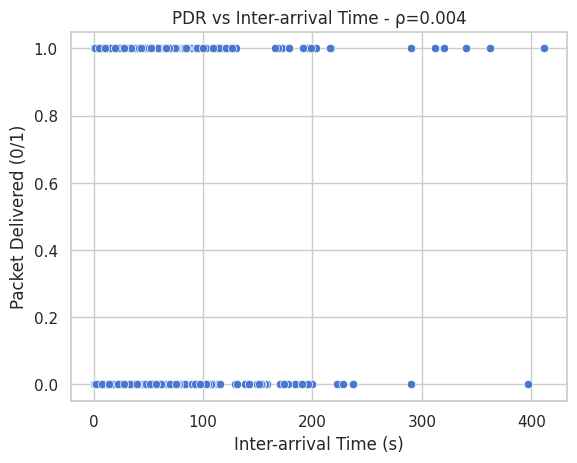

In [16]:
joined = joined[joined["_merge"] == "both"]

sns.scatterplot(
    data=joined,
    x="inter_arrival",
    y="delivered",
)
plt.xlabel("Inter-arrival Time (s)")
plt.ylabel("Packet Delivered (0/1)")
plt.title(f"PDR vs Inter-arrival Time - ρ={np.corrcoef(joined['inter_arrival'], joined['delivered'])[0,1]:.3f}")
plt.show()

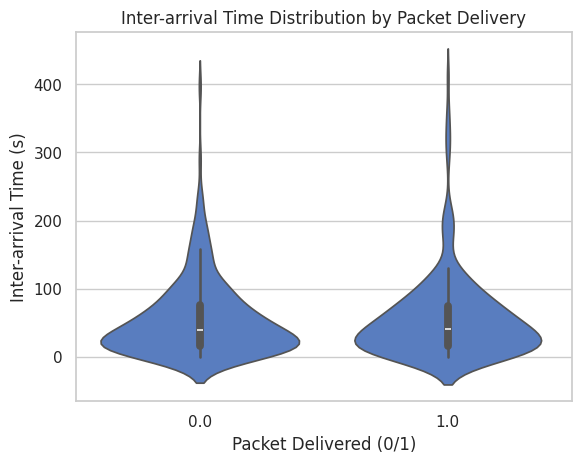

In [17]:
sns.violinplot(
    data=joined,
    x="delivered",
    y="inter_arrival",
)
plt.xlabel("Packet Delivered (0/1)")
plt.ylabel("Inter-arrival Time (s)")
plt.title("Inter-arrival Time Distribution by Packet Delivery")
plt.show()


In [18]:
def compute_optimal_beta(
    metrics: list,
    control_vars: list,
) -> float:
    """
    Computes the optimal beta coefficient for Control Variates.

    Args:
        metrics (list): List of metric values (X).
        control_vars (list): List of control variable values (Y).

    Returns:
        beta (float): Optimal beta coefficient.
    """
    X = np.array(metrics)
    Y = np.array(control_vars)
    assert len(Y) == len(X), "Metrics and control variables must have the same length."
    assert len(Y) > 1, "At least two data points are required."

    cov_XY = np.cov(X, Y, ddof=1)[0, 1]
    var_Y = np.var(Y, ddof=1)
    assert not math.isnan(cov_XY), "Covariance computation resulted in NaN."
    assert not math.isnan(var_Y), "Variance computation resulted in NaN."
    assert var_Y != 0, "Variance of control variable Y is zero."

    beta = -(cov_XY / var_Y)

    return beta


def cv_variance_reduction(
    metrics: list[float],
    control_vars: list[float],
    true_control_mean: float,
    beta: float | None = None,
) -> list[float]:
    """
    Applies Control Variates variance reduction technique.

    Args:
        metrics (list): List of metric values (X).
        control_vars (list): List of control variable values (Y).
        true_control_mean (float): True mean of the control variable (mu_Y).
        beta (float | None): Precomputed beta coefficient. If None, it will be computed.

    Returns:
        X_cv (float): Control variate adjusted metrics.
    """
    X = np.array(metrics)
    Y = np.array(control_vars)

    if len(X) != len(Y):
        raise ValueError()

    if beta is None:
        beta = compute_optimal_beta(metrics, control_vars)

    X_cv = X + beta * (Y - true_control_mean)

    return X_cv

In [19]:
CHANNEL_TO_ANALYZE = "stable"
METRIC_TO_ANALYZE = "latency"

channel_res = [c for c in topo_res.channels if c.channel_type == CHANNEL_TO_ANALYZE][0]


print(f"Channel: {channel_res.channel_type}")

Channel: stable


In [66]:
all_corrs = []

for topo_res in res.topologies:
    for channel_res in topo_res.channels:
        all_X_vals = []
        all_Y_vals = []
        for rep in channel_res.repetitions:
            if rep.latency_df is None:
                continue

            ia_df = rep.compute_interarrivals()
            ia_df[ia_df["event"] == "SEND"]
            ia_df["source_addr"] = ia_df["node_id"].map(
                lambda x: int(x.split("-")[1]).to_bytes(2, "big").hex()
            )
            ia_df["send_time"] = ia_df["time"]

            if rep.latency_df.source_addr.dtype == "int64":
                rep.latency_df.source_addr = rep.latency_df.source_addr.map(
                    lambda x: x.to_bytes(2, "big").hex()
                )

            try:
                joined = ia_df.merge(
                    rep.latency_df, on=["source_addr", "seq_num", "send_time"], how="right"
                ).dropna(subset="inter_arrival")

                all_X_vals += joined.latency.tolist()
                all_Y_vals += joined.inter_arrival.tolist()

            except Exception as e:
                print(f"Failed sim {rep.id}")
                raise (e)
        corr = np.corrcoef(all_X_vals, all_Y_vals)[0, 1]
        all_corrs.append(
            {
                "topology": topo_res.topology_type,
                "channel": channel_res.channel_type,
                "correlation": corr,
                "metric" : "latency"
            }
        )

df_corrs = pd.DataFrame(all_corrs)

/home/simone/uni/spe/SPE-project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/simone/uni/spe/SPE-project/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/simone/uni/spe/SPE-project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/simone/uni/spe/SPE-project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/simone/uni/spe/SPE-project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [67]:
all_corrs = []

for topo_res in res.topologies:
    for channel_res in topo_res.channels:
        all_X_vals = []
        all_Y_vals = []
        for rep in channel_res.repetitions:
            if rep.pdr_df is None:
                continue

            ia_df = rep.compute_interarrivals()
            ia_df[ia_df["event"] == "SEND"]
            ia_df["source_addr"] = ia_df["node_id"].map(
                lambda x: int(x.split("-")[1]).to_bytes(2, "big").hex()
            )
            ia_df["dest_addr"] = ia_df["dest"]

            if rep.pdr_df.source_addr.dtype == "int64":
                rep.pdr_df.source_addr = rep.pdr_df.source_addr.map(
                    lambda x: x.to_bytes(2, "big").hex()
                )

            try:
                joined = ia_df.merge(
                    rep.pdr_df, on=["source_addr", "seq_num", "dest_addr"], how="right"
                ).dropna(subset="inter_arrival")

                all_X_vals += joined.delivered.tolist()
                all_Y_vals += joined.inter_arrival.tolist()

            except Exception as e:
                print(f"Failed sim {rep.id}")
                raise (e)
        corr = np.corrcoef(all_X_vals, all_Y_vals)[0, 1]
        all_corrs.append(
            {
                "topology": topo_res.topology_type,
                "channel": channel_res.channel_type,
                "correlation": corr,
                "metric" : "pdr"
            }
        )

df_corrs = pd.concat([df_corrs, pd.DataFrame(all_corrs)])

/home/simone/uni/spe/SPE-project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/simone/uni/spe/SPE-project/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/simone/uni/spe/SPE-project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/simone/uni/spe/SPE-project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/simone/uni/spe/SPE-project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


In [68]:
df_corrs = df_corrs.reset_index(drop=True)
# Order by correlation
df_corrs = df_corrs.sort_values(by="correlation", ascending=False).reset_index(drop=True)

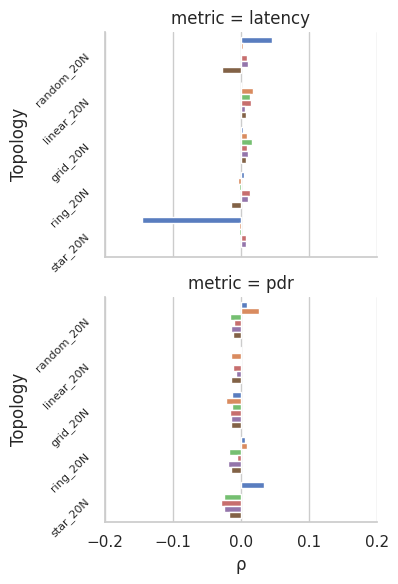

In [94]:
facet = sns.FacetGrid(
    df_corrs,
    # col="metric",
    row="metric",
    # row="topology",
    sharex=True,
    aspect=1.5,
)
facet.map_dataframe(
    sns.barplot,
    x="correlation",
    # y="channel",
    # hue="topology",
    y="topology",
    hue="channel",
    palette="muted",
    # edgecolor=".6",
)

# facet.set_xlim(-1, 1)
# facet.set(xlim=(-1, 1))
facet.set(xlim=(-0.2, 0.2))
facet.set_yticklabels(rotation=45, fontsize=8)
facet.set_axis_labels("ρ", "Topology")
facet.set_titles(col_template="{col_name}")
# facet.add_legend(title="Topology Type")
plt.show()

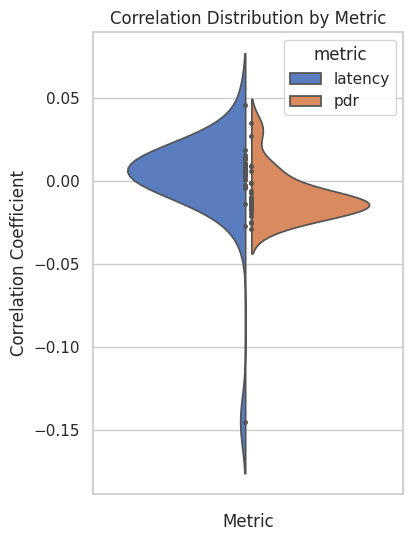

In [112]:
fig, ax = plt.subplots(figsize=(4, 6))

sns.violinplot(
    data=df_corrs,
    y="correlation",
    hue="metric",
    split=True,
    inner="point",
    gap=0.05,
    ax=ax,
)
plt.xlabel("Metric")
plt.ylabel("Correlation Coefficient")
plt.title("Correlation Distribution by Metric")
plt.show()

In [22]:
df_corrs.describe()

,correlation
count,58.000000
mean,-0.004105
std,0.024199
min,-0.145094
25%,-0.014175
50%,-0.002138
75%,0.008299
max,0.045691


In [23]:
all_X_vals = []
all_Y_vals = []

for rep in channel_res.repetitions:
    if rep.latency_df is None:
        continue

    ia_df = rep.compute_interarrivals()
    ia_df[ia_df["event"] == "SEND"]
    ia_df["source_addr"] = ia_df["node_id"].map(
        lambda x: int(x.split("-")[1]).to_bytes(2, "big").hex()
    )
    ia_df["send_time"] = ia_df["time"]

    if rep.latency_df.source_addr.dtype == "int64":
        rep.latency_df.source_addr = rep.latency_df.source_addr.map(
            lambda x: x.to_bytes(2, "big").hex()
        )

    try:
        joined = ia_df.merge(
            rep.latency_df, on=["source_addr", "seq_num", "send_time"], how="right"
        ).dropna(subset="inter_arrival")

        all_X_vals += joined.latency.tolist()
        all_Y_vals += joined.inter_arrival.tolist()

    except Exception as e:
        print(f"Failed sim {rep.id}")
        raise (e)

beta = compute_optimal_beta(all_X_vals, all_Y_vals)
print(f"corr: {np.corrcoef(all_X_vals, all_Y_vals)[0,1]}")

corr: 0.00330988520259952


In [24]:
all_X_vals = []
all_Y_vals = []

for rep in channel_res.repetitions:
    if rep.pdr_df is None:
        continue

    ia_df = rep.compute_interarrivals()
    ia_df[ia_df["event"] == "SEND"]
    ia_df["source_addr"] = ia_df["node_id"].map(
        lambda x: int(x.split("-")[1]).to_bytes(2, "big").hex()
    )
    ia_df["dest_addr"] = ia_df["dest"]

    if rep.pdr_df.source_addr.dtype == "int64":
        rep.pdr_df.source_addr = rep.pdr_df.source_addr.map(
            lambda x: x.to_bytes(2, "big").hex()
        )

    try:
        joined = ia_df.merge(
            rep.pdr_df, on=["source_addr", "seq_num", "dest_addr"], how="right"
        ).dropna(subset="inter_arrival")

        all_X_vals += joined.delivered.tolist()
        all_Y_vals += joined.inter_arrival.tolist()
    

    except Exception as e:
        print(f"Failed sim {rep.id}")
        raise (e)

beta = compute_optimal_beta(all_X_vals, all_Y_vals)
print(f"corr: {np.corrcoef(all_X_vals, all_Y_vals)[0,1]}")

corr: -0.012447539622423315


In [25]:
cv_metrics = []
raw_metric = []

for rep in channel_res.repetitions:
    if rep.pdr_df is None:
        cv_metrics.append(0)
        raw_metric.append(0)
        continue

    raw_mean_pdr = np.mean(rep.pdr_df["delivered"])
    raw_metric.append(raw_mean_pdr)

    if len(rep.pdr_df) <= 2:
        cv_metrics.append(raw_mean_pdr)
        continue

    ia_df = rep.compute_interarrivals()
    ia_df[ia_df["event"] == "SEND"]
    ia_df["source_addr"] = ia_df["node_id"].map(
        lambda x: int(x.split("-")[1]).to_bytes(2, "big").hex()
    )
    ia_df["dest_addr"] = ia_df["dest"]

    if rep.pdr_df.source_addr.dtype == "int64":
        rep.pdr_df.source_addr = rep.pdr_df.source_addr.map(
            lambda x: x.to_bytes(2, "big").hex()
        )

    try:
        joined = ia_df.merge(
            rep.pdr_df, on=["source_addr", "seq_num", "dest_addr"], how="right"
        ).dropna(subset="inter_arrival")

        cv_metric = cv_variance_reduction(
            metrics=joined["delivered"],
            control_vars=joined["inter_arrival"],
            true_control_mean=rep.mean_inter_arrival_time,
            beta=beta
        )
    except Exception as e:
        print(f"Failed sim {rep.id}")
        raise (e)
    cv_metrics.append(np.mean(cv_metric))

assert len(raw_metric) == len(cv_metrics)

## Conclusions!

After trying to use the control variate technique with the inter-arrival times as the control variate, with both e2e latecy and pdr, when estimating the $\beta$ coefficient on the metric and the control variate series we found that the $\rho \approx \pm 0.04$, for the different metrics, topologies and channels. Since the theoretical variance reduction is given by $\rho^2$ we can conclude that the control variate technique is not effective in this case, since the variance reduction is in the best case of 0.16% which is negligible and is most likely going to be lost in the noise of the estimation process or even produce a variance increase instead of a reduction due to the estimation noise.

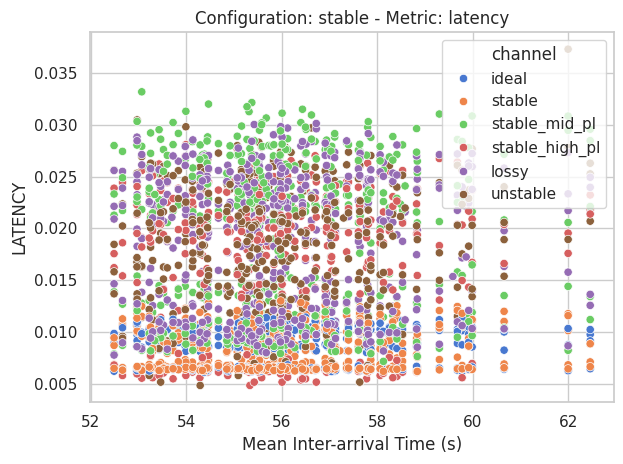

In [26]:
sns.scatterplot(data=results, x="mean_interarrival", y=METRIC_TO_ANALYZE, hue="channel")
plt.title(f"Configuration: {CHANNEL_TO_ANALYZE} - Metric: {METRIC_TO_ANALYZE}")
plt.xlabel("Mean Inter-arrival Time (s)")
plt.ylabel(METRIC_TO_ANALYZE.upper())
plt.tight_layout()
plt.show()

> [!warning]
> The following code cell is not really something significant for the analysis.

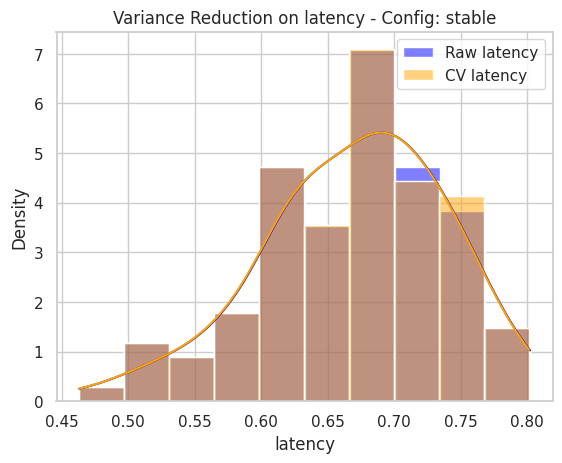

Var CV: 0.004734677732681827
Var RW: 0.004738105911648633


In [27]:
BINS = 10

sns.histplot(
    raw_metric,
    color="blue",
    label=f"Raw {METRIC_TO_ANALYZE}",
    kde=True,
    stat="density",
    bins=BINS,
)
sns.histplot(
    cv_metrics,
    color="orange",
    label=f"CV {METRIC_TO_ANALYZE}",
    kde=True,
    stat="density",
    bins=BINS,
)
plt.legend()
plt.title(f"Variance Reduction on {METRIC_TO_ANALYZE} - Config: {CHANNEL_TO_ANALYZE}")
plt.xlabel(METRIC_TO_ANALYZE)
plt.ylabel("Density")
plt.show()

print(f"Var CV: {np.var(cv_metrics)}")
print(f"Var RW: {np.var(raw_metric)}")